In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import yaml

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

## Configuration

In [3]:
batch_size = 60
seed = 42

num_classes = 10
learning_rate = 0.01
num_epochs = 60
in_channels = 1

patience = 7

## Set global seed

In [4]:
def seed_all(seed=42):
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  np.random.seed(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  random.seed(seed)

## Load the dataset MNIST using datasets

In [5]:
import copy
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.transforms as transforms
def get_data_loader(train_batch_size, config_path=None):
    if config_path is not None:
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
            train_batch_size = config.get('train_batch_size', train_batch_size)

    train_transform = transforms.Compose([
        transforms.RandomRotation(10),
        transforms.RandomAffine(
            degrees=0, 
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
            shear=10
        ), 
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset_source = datasets.MNIST(root="./data", train=True, transform=train_transform, download=True)

    val_dataset_source = datasets.MNIST(root="./data", train=True, transform=test_transform, download=True)
    test_dataset = datasets.MNIST(root="./data", train=False, transform=test_transform, download=True)

    total_count = len(train_dataset_source)
    val_split = 0.08
    val_size = int(total_count * val_split)
    train_size = total_count - val_size
    
    generator = torch.Generator().manual_seed(seed)
    train_subset, val_subset = random_split(train_dataset_source, [train_size, val_size], generator=generator)
    
    val_subset.dataset = val_dataset_source 

    train_loader = DataLoader(dataset=train_subset, batch_size=train_batch_size, shuffle=True)
    val_loader = DataLoader(dataset=val_subset, batch_size=train_batch_size, shuffle=False)
    test_loader = DataLoader(dataset=test_dataset, batch_size=train_batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [6]:
train_loader, val_loader, test_loader = get_data_loader(batch_size)
print(len(train_loader), len(val_loader), len(test_loader))

920 80 167


In [7]:
def show_image(img):
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()

In [8]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
labels

tensor([0, 1, 4, 9, 8, 4, 2, 9, 1, 1, 1, 7, 2, 9, 8, 0, 3, 1, 4, 7, 9, 7, 5, 1,
        0, 8, 6, 8, 8, 4, 6, 9, 4, 5, 7, 3, 5, 4, 1, 1, 2, 0, 9, 4, 4, 3, 9, 9,
        1, 7, 4, 4, 1, 7, 0, 4, 7, 5, 5, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


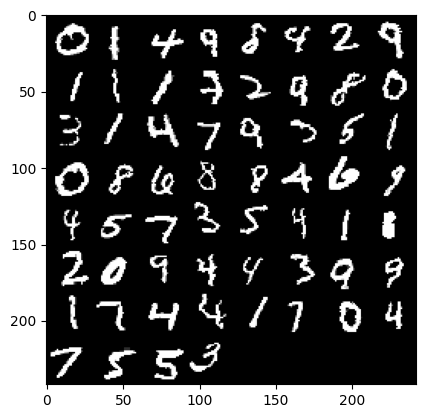

In [9]:
show_image(torchvision.utils.make_grid(images))

## Define the CNN architecture

In [10]:
class CNN(nn.Module):
  def __init__(self, in_channels, num_classes):
    super(CNN, self).__init__()
    # 1st convolutional layer
    self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # Max-pooling layer
    self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
    # 2nd convolutional layer
    self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    # fully connected layer
    self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

  def forward(self, x):
    x = F.relu(self.conv1(x))
    x = self.pool(x)
    x = F.relu(self.conv2(x))
    x = self.pool(x)

    x = x.reshape(x.shape[0], -1)
    x = self.fc1(x)

    return x


In [11]:
class MultiLayerCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(MultiLayerCNN, self).__init__()
        
        self.conv1_1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(64)
        
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(128)
        
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(0.4)
        self.flat_features = 256 * 3 * 3
        
        self.fc1 = nn.Linear(self.flat_features, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = self.pool(F.relu(self.bn1_2(self.conv1_2(x))))
        
        # Block 2
        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = self.pool(F.relu(self.bn2_2(self.conv2_2(x))))
        
        # Block 3
        x = F.relu(self.bn3_1(self.conv3_1(x)))
        x = self.pool(F.relu(self.bn3_2(self.conv3_2(x))))

        # Flatten
        x = x.reshape(x.shape[0], -1)

        # FC layers
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = F.relu(x)
        
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

## Create model

### Define device

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### create model and turn to device to prepare

In [13]:
#cnn_model = CNN(in_channels=in_channels, num_classes=num_classes).to(device)
cnn_model = MultiLayerCNN(in_channels=in_channels, num_classes=num_classes).to(device)

In [14]:
print(cnn_model)

MultiLayerCNN(
  (conv1_1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1_1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2_1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2_2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3_1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3_2): BatchNorm2d(256, eps=1e-05, momentum

## Early Stopping class

In [15]:
class EarlyStopping:
  def __init__(self, patience=patience, verbose=False, delta=0, path='best_checkpoint.pt'):
    self.patience = patience
    self.verbose = verbose
    self.counter = 0

    self.best_score = None
    self.early_stop = False
    self.val_loss_min = np.inf
    self.delta = delta
    self.path = path

  def __call__(self, val_loss, model):
    score = -val_loss
    if self.best_score is None:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta:
      self.counter += 1
      if self.verbose:
        print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
      if self.counter >= self.patience:
        self.early_stop = True
    else:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter = 0

  def save_checkpoint(self, val_loss, model):
    if self.verbose:
      print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...")
    torch.save(model.state_dict(), self.path)
    self.val_loss_min = val_loss

  def load_checkpoint(self, model):
    model.load_state_dict(torch.load(self.path))
    model.eval()
    print("Model loaded from checkpoint")

## Define the loss function and optimizer

In [16]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(cnn_model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=0.0001)
# optimizer = optim.Adam(cnn_model.parameters(), lr=learning_rate, weight_decay=0.0001)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

## Training loop

In [17]:
import torch
import numpy as np
from tqdm import tqdm

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

early_stopping = EarlyStopping(patience=patience, verbose=True, path='./best_checkpoint_optimized.pt')

for epoch in range(num_epochs):
    cnn_model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Train")

    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device=device)
        targets = targets.to(device=device)

        # Forward
        scores = cnn_model(data)
        loss = criterion(scores, targets)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate
        running_train_loss += loss.item()
        _, predictions = scores.max(1)
        train_correct += (predictions == targets).sum().item()
        train_total += targets.size(0)

        loop.set_postfix(loss=loss.item())

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = train_correct / train_total

    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)

    cnn_model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for data, targets in val_loader:
            data = data.to(device=device)
            targets = targets.to(device=device)

            scores = cnn_model(data)
            loss = criterion(scores, targets)

            running_val_loss += loss.item()
            _, predictions = scores.max(1)
            val_correct += (predictions == targets).sum().item()
            val_total += targets.size(0)

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']

    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)

    print(f"\tTrain loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f}")
    print(f"\tVal loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}")
    print(f"\tLR: {current_lr:.6f}")
    early_stopping(epoch_val_loss, cnn_model)
    # scheduler.step(epoch_val_loss)
    scheduler.step()

    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

Epoch [1/60] - Train:   0%|          | 0/920 [00:00<?, ?it/s]

Epoch [1/60] - Train:  22%|██▏       | 204/920 [00:05<00:18, 38.57it/s, loss=0.69] 


KeyboardInterrupt: 

# Final evaluation

In [ ]:
cnn_model.load_state_dict(torch.load('./best_checkpoint_optimized.pt'))
cnn_model.eval()

num_correct = 0
num_samples = 0
with torch.no_grad():
  for data, targets in test_loader:
    data = data.to(device=device)
    targets = targets.to(device=device)
    scores = cnn_model(data)
    _, predictions = scores.max(1)
    num_correct += (predictions == targets).sum()
    num_samples += predictions.size(0)

print(f'Test accuracy: {float(num_correct)/float(num_samples)*100:.2f}% ')

Test accuracy: 99.68%


## Visualization

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_metrics(train_losses, val_losses, train_accs=None, val_accs=None):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    if train_accs and val_accs:
        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label='Train Accuracy')
        plt.plot(val_accs, label='Val Accuracy')
        plt.title('Accuracy over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def get_all_preds(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

def plot_confusion_matrix(model, loader, device, classes=None):
    preds, labels = get_all_preds(model, loader, device)
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=classes if classes else "auto",
                yticklabels=classes if classes else "auto")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

def show_misclassified_images(model, loader, device, classes=None, num_images=10):
    preds, labels = get_all_preds(model, loader, device)
    misclassified_idxs = np.where(preds != labels)[0]

    if len(misclassified_idxs) == 0:
        return

    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(misclassified_idxs[:num_images]):
        dataset = loader.dataset
        image, label = dataset[idx]
        pred_label = preds[idx]

        image = image.numpy().squeeze()

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')

        true_text = classes[label] if classes else str(label)
        pred_text = classes[pred_label] if classes else str(pred_label)

        plt.title(f"True: {true_text}\nPred: {pred_text}", color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

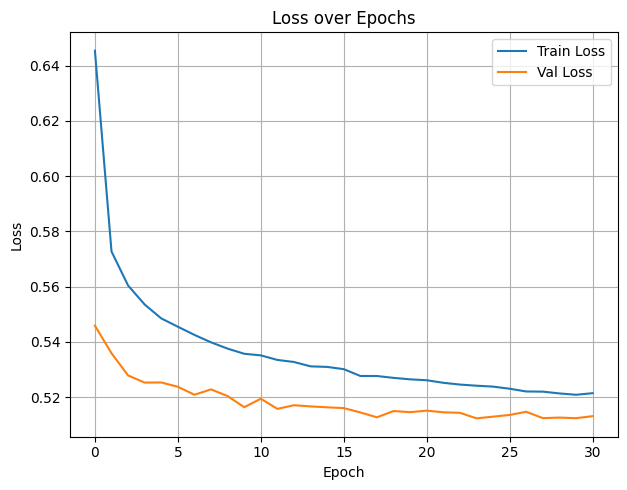

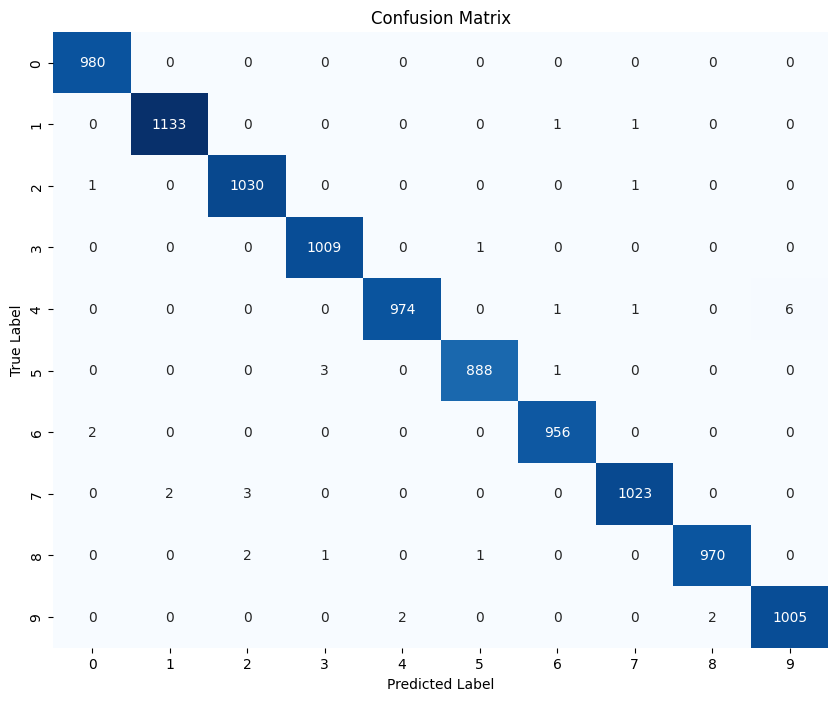

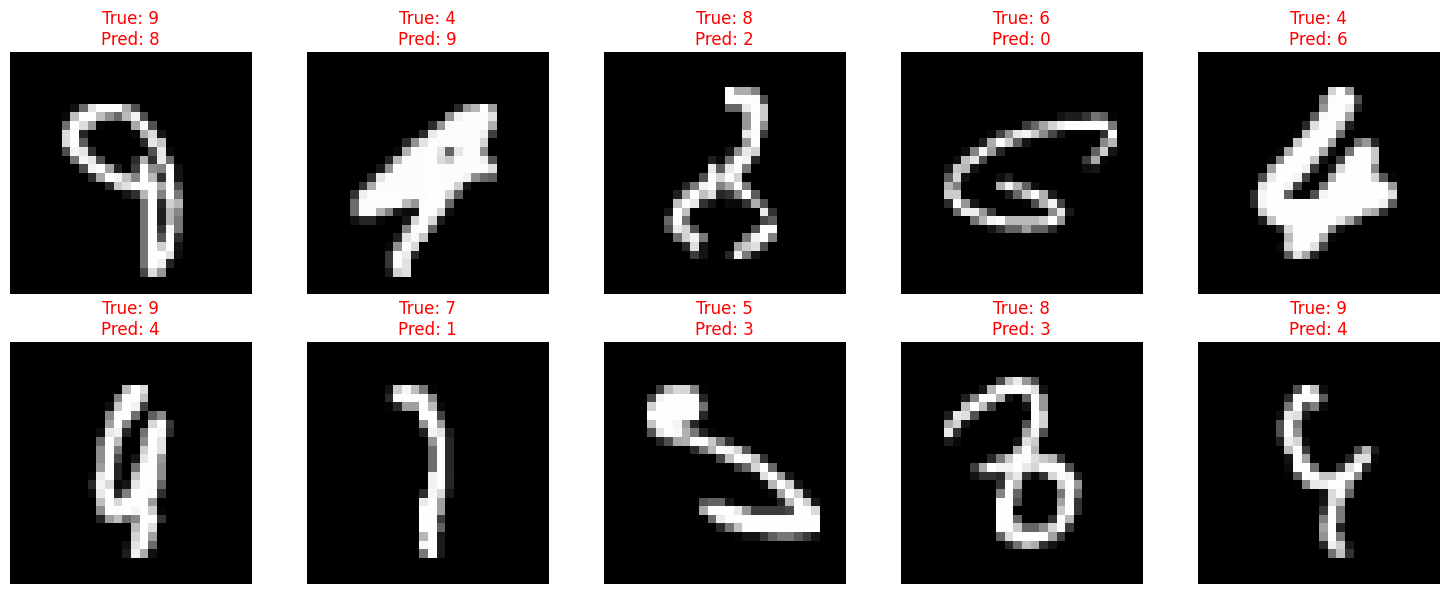

In [ ]:
plot_metrics(train_loss_history, val_loss_history)
plot_confusion_matrix(cnn_model, test_loader, device, classes=[str(i) for i in range(10)])
show_misclassified_images(cnn_model, test_loader, device, classes=[str(i) for i in range(10)], num_images=10)

In [18]:
import os
import torch
import math
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from torchvision import transforms
import torch.nn.functional as F

def predict_mnist_real_world(model, device, root_dir='./test_mnist'):
    class_names = [str(i) for i in range(10)]
    
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    model.eval()
    image_data = []
    
    for label in class_names:
        folder_path = os.path.join(root_dir, label)
        if os.path.exists(folder_path):
            files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for f in files:
                image_data.append((os.path.join(folder_path, f), label))
    
    num_images = len(image_data)
    if num_images == 0:
        return

    cols = 5
    rows = math.ceil(num_images / cols)
    plt.figure(figsize=(15, rows * 3.5))

    with torch.no_grad():
        for i, (img_path, true_label) in enumerate(image_data):
            try:
                original_img = Image.open(img_path)
                img_inverted = ImageOps.invert(original_img.convert('RGB'))
                
                input_tensor = transform(img_inverted).unsqueeze(0).to(device)
                
                outputs = model(input_tensor)
                probs = F.softmax(outputs, dim=1)
                conf, pred_idx = torch.max(probs, 1)
                pred_label = class_names[pred_idx.item()]
                
                plt.subplot(rows, cols, i + 1)
                plt.imshow(original_img, cmap='gray')
                
                is_correct = (pred_label == true_label)
                color = 'green' if is_correct else 'red'
                
                plt.title(f"True: {true_label} | Pred: {pred_label}\nConf: {conf.item()*100:.1f}%", 
                          color=color, fontsize=10, fontweight='bold')
                plt.axis('off')
                
            except Exception:
                continue

    plt.tight_layout()
    plt.show()

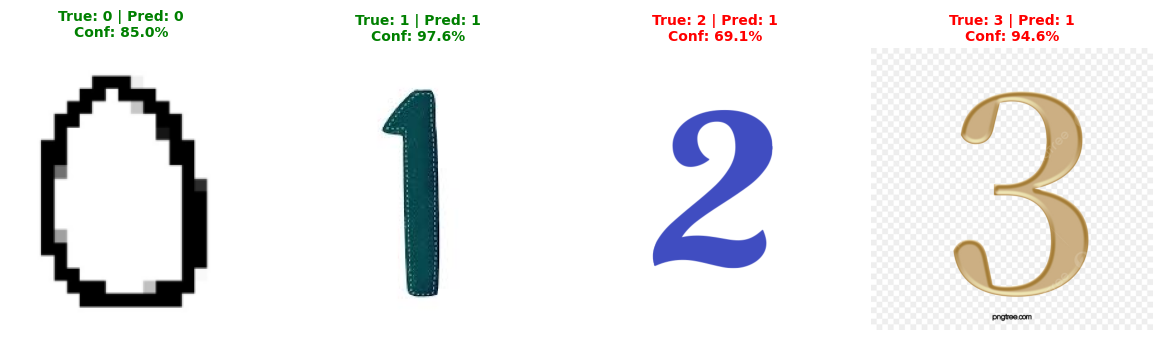

In [20]:
predict_mnist_real_world(cnn_model, device, './test_mnist')